In [1]:
from keras.datasets import reuters
(train_data, train_labels), (test_data, test_labels) = reuters.load_data(
    num_words=10000)

In [2]:
len(train_data)

8982

In [3]:
len(test_data)

2246

In [4]:
train_data[10]

[1,
 245,
 273,
 207,
 156,
 53,
 74,
 160,
 26,
 14,
 46,
 296,
 26,
 39,
 74,
 2979,
 3554,
 14,
 46,
 4689,
 4329,
 86,
 61,
 3499,
 4795,
 14,
 61,
 451,
 4329,
 17,
 12]

In [5]:
word_index = reuters.get_word_index()
reverse_word_index = dict(
    [(value, key) for (key, value) in word_index.items()])
decoded_newswire = " ".join(
    [reverse_word_index.get(i - 3, "?") for i in train_data[0]]
)

In [6]:
train_labels[10]

3

In [7]:
import numpy as np
def vertorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        for j in sequence:
            results[i, j] = 1.
    return results
x_train = vertorize_sequences(train_data)
x_test = vertorize_sequences(test_data)

In [8]:
def to_one_hot(labels, dimension=46):
    results = np.zeros((len(labels), dimension))
    for i, label in enumerate(labels):
        results[i, label] = 1
    return results

y_train = to_one_hot(train_labels)
y_test = to_one_hot(test_labels)

In [9]:
from keras.utils import to_categorical
y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)

In [10]:
import keras
from keras import layers


model = keras.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(46, activation="softmax")
])

In [11]:
model.compile(optimizer="rmsprop",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

In [12]:
x_val = x_train[:1000]
partial_x_train = x_train[1000:]
y_val = y_train[:1000]
partial_y_train = y_train[1000:]

In [13]:
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/20


16/16 [==============================] - 1s 27ms/step - loss: 2.6068 - accuracy: 0.4757 - val_loss: 1.7623 - val_accuracy: 0.6340
Epoch 2/20
16/16 [==============================] - 0s 16ms/step - loss: 1.4801 - accuracy: 0.6875 - val_loss: 1.3336 - val_accuracy: 0.7110
Epoch 3/20
16/16 [==============================] - 0s 13ms/step - loss: 1.1376 - accuracy: 0.7552 - val_loss: 1.1698 - val_accuracy: 0.7490
Epoch 4/20
16/16 [==============================] - 0s 13ms/step - loss: 0.9344 - accuracy: 0.7985 - val_loss: 1.0693 - val_accuracy: 0.7630
Epoch 5/20
16/16 [==============================] - 0s 11ms/step - loss: 0.7739 - accuracy: 0.8311 - val_loss: 0.9980 - val_accuracy: 0.7830
Epoch 6/20
16/16 [==============================] - 0s 16ms/step - loss: 0.6458 - accuracy: 0.8618 - val_loss: 0.9606 - val_accuracy: 0.7950
Epoch 7/20
16/16 [==============================] - 0s 15ms/step - loss: 0.5432 - accuracy: 0.8879 - val_loss: 0.9213 - val_accuracy: 0.8040
Epoch 8/20


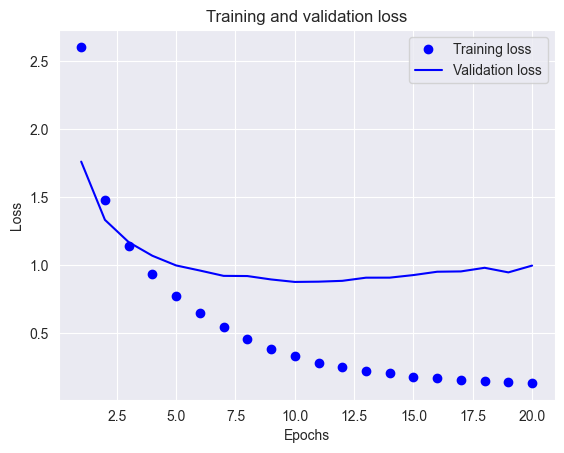

In [14]:
import matplotlib.pyplot as plt
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

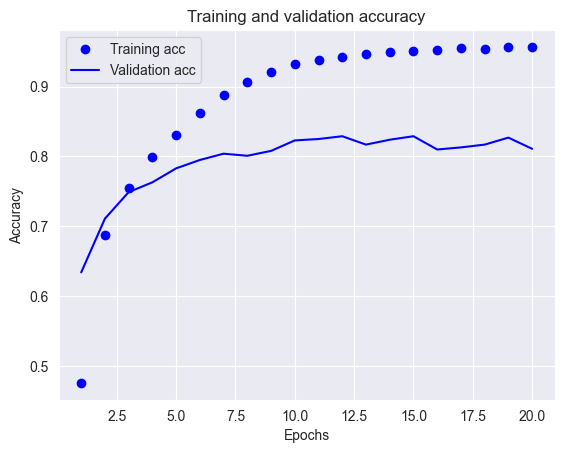

In [15]:
plt.clf()
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
plt.plot(epochs, acc, "bo", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [16]:
model = keras.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(46, activation="softmax")])

model.compile(optimizer="rmsprop",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

model.fit(x_train, y_train, epochs=9, batch_size=512)

results = model.evaluate(x_test, y_test)

Epoch 1/9
18/18 [==============================] - 1s 12ms/step - loss: 2.7117 - accuracy: 0.5155
Epoch 2/9
18/18 [==============================] - 0s 8ms/step - loss: 1.4837 - accuracy: 0.6823
Epoch 3/9
18/18 [==============================] - 0s 9ms/step - loss: 1.1163 - accuracy: 0.7516
Epoch 4/9
18/18 [==============================] - 0s 9ms/step - loss: 0.9034 - accuracy: 0.8053
Epoch 5/9
18/18 [==============================] - 0s 8ms/step - loss: 0.7416 - accuracy: 0.8378
Epoch 6/9
18/18 [==============================] - 0s 11ms/step - loss: 0.6124 - accuracy: 0.8696
Epoch 7/9
18/18 [==============================] - 0s 12ms/step - loss: 0.5090 - accuracy: 0.8930
Epoch 8/9
18/18 [==============================] - 0s 9ms/step - loss: 0.4294 - accuracy: 0.9081
Epoch 9/9
71/71 [==============================] - 0s 3ms/step - loss: 0.9150 - accuracy: 0.7956


In [17]:
results

[0.915010929107666, 0.7956367135047913]

In [18]:
import copy
test_labels_copy = copy.copy(test_labels)
np.random.shuffle(test_labels_copy)
hits_array = np.array(test_labels) ==np.array(test_labels_copy)
hits_array.mean()

0.1892252894033838

In [19]:
predictions = model.predict(x_test)

71/71 [==============================] - 0s 2ms/step


In [20]:
predictions[0].shape

(46,)

In [21]:
np.sum(predictions[0])

0.99999994

In [22]:
np.argmax(predictions[0])

3

In [23]:
y_train = np.array(train_labels)
y_test = np.array(test_labels)

In [24]:
model.compile(optimizer="rmsprop",
              loss = "sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [25]:
model = keras.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(4, activation="relu"),
    layers.Dense(46, activation="relu"),
])

In [26]:
model.compile(optimizer="rmsprop",
              loss="categorical_crossentropy",
              metrics=["accuracy"])
model.fit(partial_x_train,
          partial_y_train,
          epochs=20,
          batch_size=128,
          validation_data=(x_val,y_val))

Epoch 1/20
63/63 [==============================] - 1s 8ms/step - loss: nan - accuracy: 0.0066 - val_loss: nan - val_accuracy: 0.0060
Epoch 2/20
63/63 [==============================] - 1s 14ms/step - loss: nan - accuracy: 0.0061 - val_loss: nan - val_accuracy: 0.0060
Epoch 3/20
63/63 [==============================] - 1s 13ms/step - loss: nan - accuracy: 0.0061 - val_loss: nan - val_accuracy: 0.0060
Epoch 4/20
63/63 [==============================] - 1s 17ms/step - loss: nan - accuracy: 0.0061 - val_loss: nan - val_accuracy: 0.0060
Epoch 5/20
63/63 [==============================] - 1s 15ms/step - loss: nan - accuracy: 0.0061 - val_loss: nan - val_accuracy: 0.0060
Epoch 6/20
63/63 [==============================] - 1s 12ms/step - loss: nan - accuracy: 0.0061 - val_loss: nan - val_accuracy: 0.0060
Epoch 7/20
63/63 [==============================] - 1s 13ms/step - loss: nan - accuracy: 0.0061 - val_loss: nan - val_accuracy: 0.0060
Epoch 8/20
63/63 [==============================] - 1s 1